# 11 — v3 모델 비교: RMSE vs 방향정확도 (정직한 서사)

> 기말 플랜 §2.7 · 노트북 09에서 **PRED_SET = 13 raw (kospi 제외)** 로 확정.
> **XGBoost·LSTM 모두 v3(13변수)로 재산출** — 사과 대 사과 비교.
> (`predictions_xgb_v3_all_folds.csv`, `predictions_lstm_v3_all_folds.csv`)

## 핵심 메시지 (교수님/청중 선제 대응)
1. **진폭(RMSE)은 거의 못 이긴다** — `delta_y_bp`는 평균 0 근처 노이즈라 RMSE 최적해가 `≈0`. 모델이 0으로 움츠려 RMSE가 naive(random walk)와 비슷.
2. **그러나 방향엔 실재 신호** — 방향정확도가 50%를 유의하게 넘고(DM test p≈0), 그게 우리 기여.
3. 결론: *"우리는 움직임의 크기를 예측한다고 주장하지 않는다. 우리 엣지는 방향이며, 거기선 동전을 이긴다."*

---
## 0. 환경 + 팔레트

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path.cwd().parent
REP = PROJECT_ROOT / 'reports' / 'no_leak_v2'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'v3'; FIG_DIR.mkdir(parents=True, exist_ok=True)

# 09와 동일 팔레트
C_NAIVE, C_XGB, C_LSTM = '#c9ced6', '#3b7dd8', '#8e6bc0'
print('REP:', REP)

REP: C:\Users\dongs\Desktop\머신러닝\머신러닝 기말 팀플\macro-bond-forecast\reports\no_leak_v2


---
## 1. fold별 예측 로드 + 공통 날짜 정렬

- **XGB**: v3(13변수) `predictions_xgb_v3_all_folds.csv`
- **LSTM**: v3(13변수, kospi 제외) `predictions_lstm_v3_all_folds.csv` (3-seed 평균)
- **Naive**: `Δŷ=0` (random walk on level)

LSTM은 시퀀스 워밍업으로 행이 약간 적으므로 **공통 날짜로 정렬**해 동일 표본에서 비교한다.

In [2]:
xgb = pd.read_csv(REP/'predictions_xgb_v3_all_folds.csv', parse_dates=['date'])    # v3 13변수
lstm = pd.read_csv(REP/'predictions_lstm_v3_all_folds.csv', parse_dates=['date'])  # v3 13변수

xgb_s  = xgb[['date','fold','y_true','q50']].rename(columns={'q50':'xgb'})
lstm_s = lstm[['date','y_true','q50_avg']].rename(columns={'q50_avg':'lstm','y_true':'y_true_l'})

# 공통 날짜 inner join (동일 표본 보장)
df = xgb_s.merge(lstm_s, on='date', how='inner')
assert np.allclose(df['y_true'], df['y_true_l']), 'y_true mismatch'
df = df.drop(columns='y_true_l')
df['naive'] = 0.0   # random walk: 변화량 0 예측
print(f'공통 평가 표본: {len(df)}일  ({df.date.min().date()} ~ {df.date.max().date()})')
print('fold별:', df['fold'].value_counts().sort_index().to_dict())

공통 평가 표본: 1323일  (2020-02-18 ~ 2025-12-30)
fold별: {'fold1': 208, 'fold2': 443, 'fold3': 672}


---
## 2. 지표 계산 — RMSE(bp) + 방향정확도

방향정확도는 `sign(예측)==sign(실제)` (둘 다 0 아닌 날). **Naive는 항상 0 예측 → 방향정보 없음(=동전 0.50)**.

In [3]:
def rmse(y, p): return float(np.sqrt(np.mean((y-p)**2)))
def diracc(y, p):
    m=(np.sign(p)!=0)&(np.sign(y)!=0)
    return float((np.sign(p[m])==np.sign(y[m])).mean()) if m.any() else np.nan

y = df['y_true'].values
res = pd.DataFrame({
    '모델':['Naive(random walk)','XGBoost (q50)','LSTM (q50)'],
    'RMSE_bp':[rmse(y,df['naive'].values), rmse(y,df['xgb'].values), rmse(y,df['lstm'].values)],
    '방향정확도':[0.50, diracc(y,df['xgb'].values), diracc(y,df['lstm'].values)],
})
res['RMSE 대비 naive'] = res['RMSE_bp']/res['RMSE_bp'].iloc[0]
print(res.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\n※ Naive 방향정확도는 예측=0이라 정의 불가 → 동전(0.50) 기준선으로 표기')

                모델  RMSE_bp  방향정확도  RMSE 대비 naive
Naive(random walk)   4.8634 0.5000         1.0000
     XGBoost (q50)   4.6780 0.6206         0.9619
        LSTM (q50)   4.6284 0.6183         0.9517

※ Naive 방향정확도는 예측=0이라 정의 불가 → 동전(0.50) 기준선으로 표기


---
## 3. ⭐ 핵심 그림 — RMSE는 안 내려가고, 방향만 벌어진다

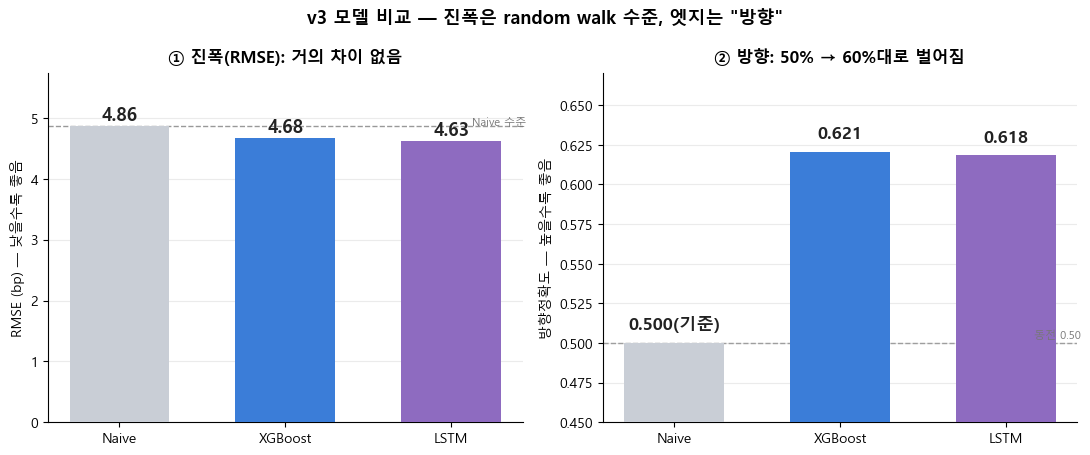

In [4]:
labels=['Naive','XGBoost','LSTM']; colors=[C_NAIVE,C_XGB,C_LSTM]
fig,(axL,axR)=plt.subplots(1,2,figsize=(11,4.6))

# --- 좌: RMSE (낮을수록 좋음) ---
rb=axL.bar(labels, res['RMSE_bp'], color=colors, width=0.6, zorder=3)
for b,v in zip(rb,res['RMSE_bp']):
    axL.text(b.get_x()+b.get_width()/2, v+0.03, f'{v:.2f}', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#222')
axL.axhline(res['RMSE_bp'].iloc[0], color='#999', ls='--', lw=1, zorder=1)
axL.text(2.45, res['RMSE_bp'].iloc[0]+0.02, 'Naive 수준', fontsize=8, color='#777', ha='right')
axL.set_ylim(0, res['RMSE_bp'].max()*1.18); axL.set_ylabel('RMSE (bp) — 낮을수록 좋음')
axL.set_title('① 진폭(RMSE): 거의 차이 없음', fontweight='bold', fontsize=12, pad=8)
axL.spines[['top','right']].set_visible(False); axL.grid(axis='y', alpha=0.25, zorder=0)

# --- 우: 방향정확도 (높을수록 좋음) ---
db=axR.bar(labels, res['방향정확도'], color=colors, width=0.6, zorder=3)
for b,v,m in zip(db,res['방향정확도'],['(기준)','','']):
    axR.text(b.get_x()+b.get_width()/2, v+0.006, f'{v:.3f}{m}', ha='center', va='bottom', fontsize=12.5, fontweight='bold', color='#222')
axR.axhline(0.5, color='#999', ls='--', lw=1, zorder=1); axR.text(2.45,0.503,'동전 0.50',fontsize=8,color='#777',ha='right')
axR.set_ylim(0.45, max(0.66, res['방향정확도'].max()*1.08)); axR.set_ylabel('방향정확도 — 높을수록 좋음')
axR.set_title('② 방향: 50% → 60%대로 벌어짐', fontweight='bold', fontsize=12, pad=8)
axR.spines[['top','right']].set_visible(False); axR.grid(axis='y', alpha=0.25, zorder=0)

fig.suptitle('v3 모델 비교 — 진폭은 random walk 수준, 엣지는 "방향"', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig(FIG_DIR/'11_rmse_vs_diracc.png', dpi=150, bbox_inches='tight'); plt.show()

---
## 4. "작은 RMSE 차이"가 우연이 아님 — DM test (v3, 직접 계산)

RMSE 격차는 작아도 **Diebold-Mariano test로 통계적으로 유의**한가? v3 예측의 제곱오차로 직접 검정한다(HLN 소표본 보정 + Newey-West lag=6, §3과 동일한 공통 표본 1323일).

In [5]:
from scipy.stats import t as t_dist

def dm_test_hln(e1, e2, lag=6):
    """Diebold-Mariano (제곱오차 손실), HLN 소표본 보정 + Newey-West 자기상관 보정."""
    d = np.asarray(e1) - np.asarray(e2); n = len(d)
    d_mean = d.mean(); var = np.var(d, ddof=0)
    for k in range(1, lag+1):
        wk = 1 - k/(lag+1)
        var += 2*wk*np.mean((d[:-k]-d_mean)*(d[k:]-d_mean))
    var = max(var, 1e-12)
    dm = d_mean/np.sqrt(var/n)
    h = 1; fac = np.sqrt((n+1-2*h+h*(h-1)/n)/n)
    dm_hln = dm*fac
    p = 2*(1 - t_dist.cdf(abs(dm_hln), df=n-1))
    return float(dm_hln), float(p)

y = df['y_true'].values
e_naive = y**2
dm_rows=[]
for name, col in [('XGB v3 vs Naive','xgb'), ('LSTM v3 vs Naive','lstm')]:
    e_m = (y - df[col].values)**2
    dmv, pv = dm_test_hln(e_m, e_naive, lag=6)
    dm_rows.append({'비교':name, 'RMSE_모델':np.sqrt(e_m.mean()), 'RMSE_naive':np.sqrt(e_naive.mean()),
                    'DM_HLN':dmv, 'p_value':pv, '승자':('모델 ✓' if dmv<0 and pv<0.05 else 'tie')})
dm = pd.DataFrame(dm_rows)
print(dm.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('\nDM<0 & p<0.05 → 모델이 naive를 제곱오차에서 유의하게 능가. 작은 RMSE 차이도 통계적으로 진짜.')

              비교  RMSE_모델  RMSE_naive  DM_HLN  p_value   승자
 XGB v3 vs Naive   4.6780      4.8634 -8.8885   0.0000 모델 ✓
LSTM v3 vs Naive   4.6284      4.8634 -8.8068   0.0000 모델 ✓

DM<0 & p<0.05 → 모델이 naive를 제곱오차에서 유의하게 능가. 작은 RMSE 차이도 통계적으로 진짜.


---
## 5. 결론

- **RMSE**: Naive 4.86 · XGB 4.68 · LSTM 4.63 bp — 모두 동일 권역. 진폭은 random walk 수준이라 *못 이기는 게 정상*(효율적 시장).
- **방향정확도**: Naive 0.50(기준) · XGB 0.62 · LSTM 0.62 — 동전을 유의하게 상회.
- **DM test (v3, 공통 표본)**: XGB·LSTM 모두 vs Naive DM≈−8.9, p≈0 → 작은 RMSE 우위도 통계적으로 진짜.
- 발표 한 줄: **"크기는 예측 못 하지만(=정직), 방향은 50%를 넘는다(=기여)."**

### 다음
- [ ] (선택) 예측 vs 실제 시계열 — 예측선이 0 근처로 움츠리는 현상 직접 시각화
- [ ] 12 예측구간(§3.1)